In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Setup and Data Loading
We’ll use Seaborn’s built-in Titanic dataset for convenience, as it is pre-cleaned for basic EDA.

In [6]:
# Set visual style
sns.set_theme(style="whitegrid")

In [7]:
# Load dataset
df = sns.load_dataset('titanic')

In [8]:
# Initial check
print("--- Data Info ---")
df.info()
print("\n--- Summary Statistics ---")
display(df.describe())

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

--- Summary Statistics ---


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


#Handling Missing Values & Basic Counts
Before plotting, we need to know what’s missing. Usually, age and embarked need attention.

In [9]:
# Check for missing values
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


/tmp/ipython-input-2589316357.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='survived', data=df, palette='viridis')


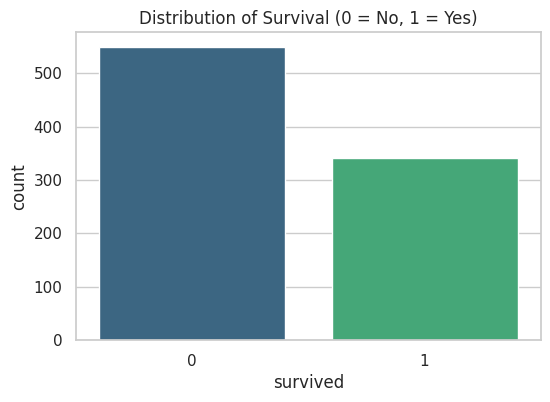

In [10]:
# Basic counts for the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='survived', data=df, palette='viridis')
plt.title('Distribution of Survival (0 = No, 1 = Yes)')
plt.show()

#Univariate Analysis (Distributions)
Let's look at Age and Fare to identify the demographic and economic spread of the passengers.

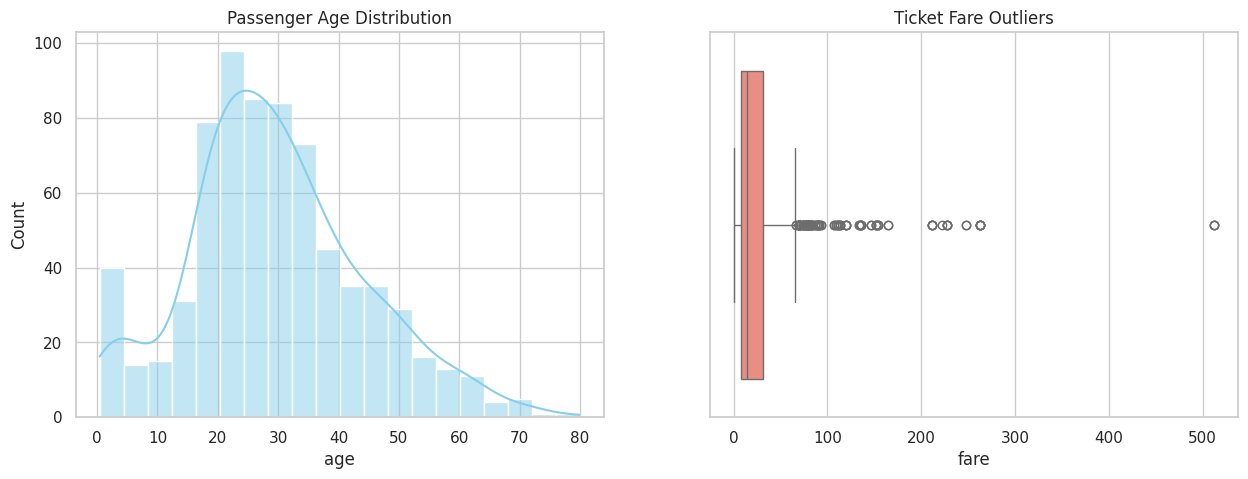

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Age Distribution
sns.histplot(df['age'].dropna(), kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Passenger Age Distribution')

# Fare Distribution (Boxplot to see outliers)
sns.boxplot(x=df['fare'], ax=axes[1], color='salmon')
axes[1].set_title('Ticket Fare Outliers')

plt.show()

#Bivariate Analysis (Relationships)
This is where we test the "Women and Children First" hypothesis and the impact of social class.

/tmp/ipython-input-1852430560.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='sex', y='survived', data=df, ci=None)


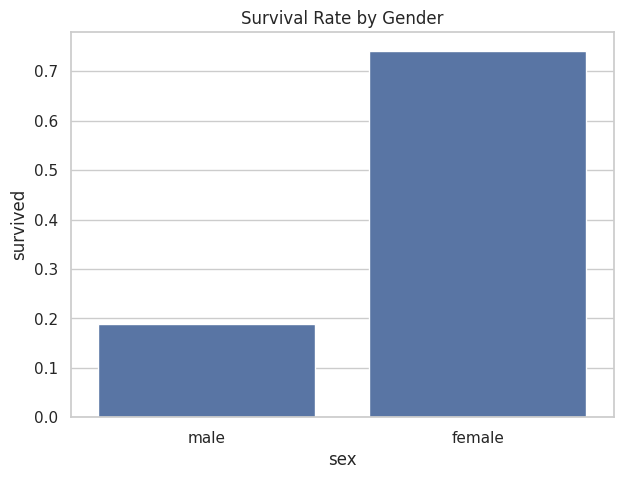

In [12]:
# 1. Survival by Sex
plt.figure(figsize=(7, 5))
sns.barplot(x='sex', y='survived', data=df, ci=None)
plt.title('Survival Rate by Gender')
plt.show()

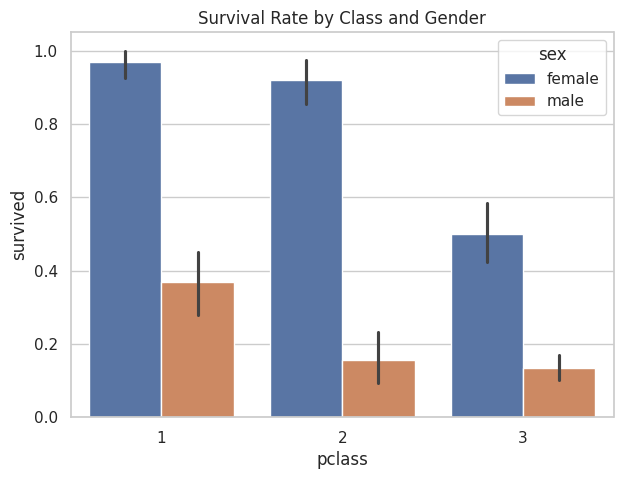

In [13]:
# 2. Survival by Class
plt.figure(figsize=(7, 5))
sns.barplot(x='pclass', y='survived', hue='sex', data=df)
plt.title('Survival Rate by Class and Gender')
plt.show()

#Multivariate Analysis (Heatmap & Pairplot)
We convert categorical data to numeric codes to see the "big picture" correlation.

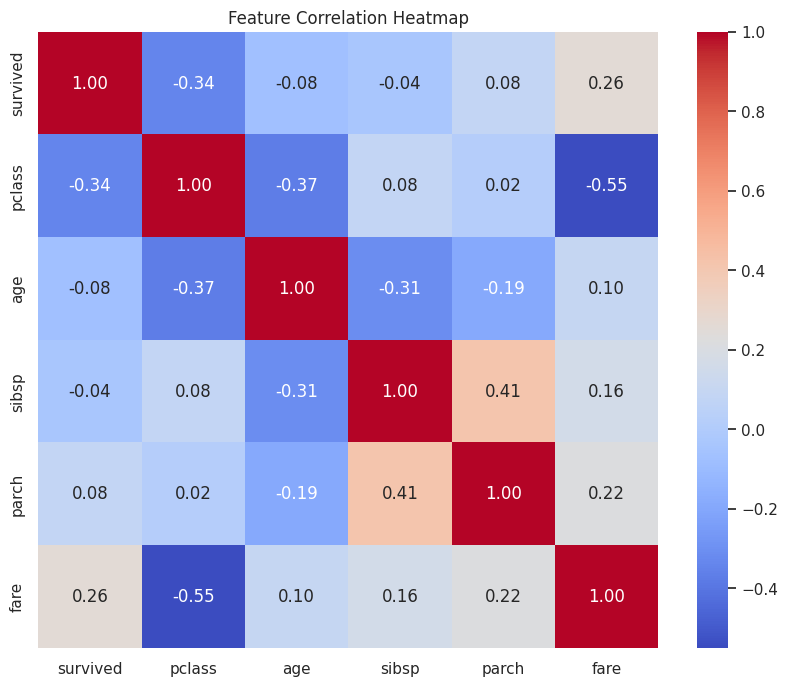

In [14]:
# Select numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

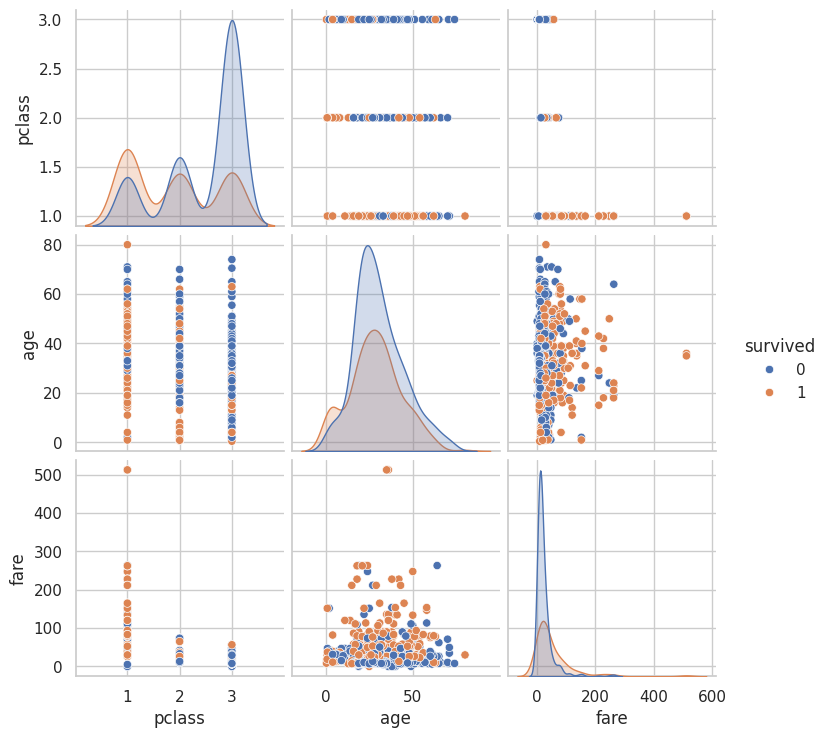

In [15]:
# Pairplot to see clusters (Sampled for speed)
sns.pairplot(df[['survived', 'pclass', 'age', 'fare']].dropna(), hue='survived')
plt.show()